# The notebook is correct Resource error is caused due to ht ememory limitation use in colab to make things correct

In [1]:
import numpy as np
from keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


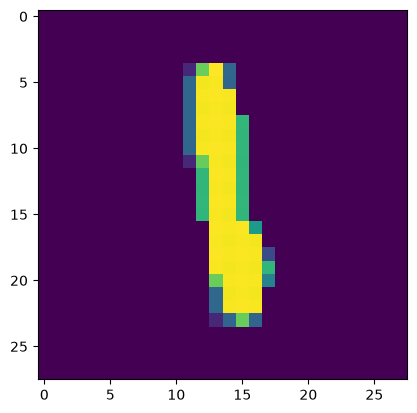

Label for the element 200 : 1
(60000, 784)
(10000, 784)


In [2]:
element = 200
plt.imshow(x_train[element])
plt.show()
print("Label for the element", element,":", y_train[element])
x_train = x_train.reshape((-1, 28*28))
x_test = x_test.reshape((-1, 784))
print(x_train.shape)
print(x_test.shape)
x_train = x_train / 255
x_test = x_test / 255

In [3]:
from keras.models import Sequential
from keras.utils import to_categorical
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import BatchNormalization

# 1st Convolution layer

In [4]:
model = Sequential()  
model.add(Conv2D(filters = 96, input_shape = (60000,784, 3),kernel_size = (11, 11), strides = (4, 4), padding = 'valid')) 
model.add(Activation('relu')) 
model.add(MaxPooling2D(pool_size = (2, 2),strides = (2, 2), padding = 'valid')) 
model.add(BatchNormalization())

c:\Users\umair\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 2nd Convolution layer

In [5]:
model.add(Conv2D(filters = 384, kernel_size = (3, 3),strides = (1, 1), padding = 'valid')) 
model.add(Activation('relu')) 
model.add(BatchNormalization()) 

# 3rd Convolution layer

In [6]:
model.add(Conv2D(filters = 384, kernel_size = (3, 3),strides = (1, 1), padding = 'valid')) 
model.add(Activation('relu')) 
model.add(BatchNormalization()) 

# 4th Convolution layer

In [7]:
model.add(Conv2D(filters = 384, kernel_size = (3, 3),strides = (1, 1), padding = 'valid')) 
model.add(Activation('relu')) 
model.add(BatchNormalization())

# 5th Convolution layer

In [8]:
model.add(Conv2D(filters = 256, kernel_size = (3, 3),strides = (1, 1), padding = 'valid')) 
model.add(Activation('relu')) 
model.add(MaxPooling2D(pool_size = (2, 2), strides = (2, 2), padding = 'valid')) 
model.add(BatchNormalization()) 

In [9]:
# Flattening 
model.add(Flatten()) 

1st Dense Layer

In [18]:
model.add(Dense(2, input_shape = (224*224*3, ), use_bias=False)) 
model.add(Activation('relu')) 
model.add(Dropout(0.4)) 
model.add(BatchNormalization()) 

ResourceExhaustedError: {{function_node __wrapped__StatelessRandomUniformV2_device_/job:localhost/replica:0/task:0/device:CPU:0}} OOM when allocating tensor with shape[42183680,4096] and type float on /job:localhost/replica:0/task:0/device:CPU:0 by allocator mklcpu [Op:StatelessRandomUniformV2] name: 

2nd Dense Layer

In [12]:
model.add(Dense(4096)) 
model.add(Activation('relu')) 

model.add(Dropout(0.4)) 
model.add(BatchNormalization()) 

ResourceExhaustedError: {{function_node __wrapped__StatelessRandomUniformV2_device_/job:localhost/replica:0/task:0/device:CPU:0}} OOM when allocating tensor with shape[42183680,4096] and type float on /job:localhost/replica:0/task:0/device:CPU:0 by allocator mklcpu [Op:StatelessRandomUniformV2] name: 

In [13]:
# Output Softmax Layer 
model.add(Dense(10)) 
model.add(Activation('softmax'))

ResourceExhaustedError: {{function_node __wrapped__StatelessRandomUniformV2_device_/job:localhost/replica:0/task:0/device:CPU:0}} OOM when allocating tensor with shape[42183680,4096] and type float on /job:localhost/replica:0/task:0/device:CPU:0 by allocator mklcpu [Op:StatelessRandomUniformV2] name: 

In [19]:
model.compile(optimizer='Adam',loss='categorical_crossentropy',metrics=['accuracy'])
y=to_categorical(y_train)

In [21]:
model.fit(x=x_train,y=to_categorical(y_train),epochs=10,batch_size=64,shuffle=True)


Epoch 1/10


ValueError: Sequential model 'sequential' has already been configured to use input shape (None, 60000, 784, 3). You cannot build it with input_shape (None, 784)

In [22]:
eval = model.evaluate(x_test, to_categorical(y_test))
print('eval')

ValueError: Sequential model 'sequential' has already been configured to use input shape (None, 60000, 784, 3). You cannot build it with input_shape (None, 784)

In [23]:
predictions = model.predict(x_test[0:100])
predictions[0]
np.argmax(predictions[0])
plt.imshow(x_test[0].reshape(28,28))

ValueError: Sequential model 'sequential' has already been configured to use input shape (None, 60000, 784, 3). You cannot build it with input_shape (32, 784)